In [1]:
from LandcoverDataset import LandcoverDataset as LD
from Model import CNN
from utils import *

import torch
import torch.nn as nn
from torchviz import make_dot

import matplotlib.pyplot as plt

In [2]:
INDEXES = {
    "BI": "((S1 + R) - (N + B))/((S1 + R) + (N + B))",
    "BNDVI": "(N - B)/(N + B)",
    "MGRVI": "(G ** 2.0 - R ** 2.0) / (G ** 2.0 + R ** 2.0)",
    "NDCI": "(RE1 - R)/(RE1 + R)",
    "NLI": "((N ** 2) - R)/((N ** 2) + R)",
}

In [3]:
BATCH = 8
N_CLASSES = 5

In [4]:
TRAIN_noindex = LD(
    img_path="/mnt/nas/storage/alex/datasets_smiles2024/USA/train/images/",
    mask_path="/mnt/nas/storage/alex/datasets_smiles2024/USA/train/masks/",
    batch_size=BATCH,
    indexes=[],
    cpu_cores = 4
)
TRAIN_with_index = LD(
    img_path="/mnt/nas/storage/alex/datasets_smiles2024/USA/train/images/",
    mask_path="/mnt/nas/storage/alex/datasets_smiles2024/USA/train/masks/",
    batch_size=BATCH,
    indexes=list(INDEXES.values()),
    cpu_cores = 4
)


VALIDATION_noindex = LD(
    img_path="/mnt/nas/storage/alex/datasets_smiles2024/USA/valid/images/",
    mask_path="/mnt/nas/storage/alex/datasets_smiles2024/USA/valid/masks/",
    batch_size=BATCH,
    transforms=False,
    indexes=[],
    cpu_cores = 4
)
VALIDATION_with_index = LD(
    img_path="/mnt/nas/storage/alex/datasets_smiles2024/USA/valid/images/",
    mask_path="/mnt/nas/storage/alex/datasets_smiles2024/USA/valid/masks/",
    batch_size=BATCH,
    transforms=False,
    indexes=list(INDEXES.values()),
    cpu_cores = 4
)


TEST_noindex = LD(
    img_path="/mnt/nas/storage/alex/datasets_smiles2024/Russia/test/images/",
    mask_path="/mnt/nas/storage/alex/datasets_smiles2024/Russia/test/masks/",
    batch_size=BATCH,
    transforms=False,
    indexes=[],
    cpu_cores = 4
)
TEST_with_index = LD(
    img_path="/mnt/nas/storage/alex/datasets_smiles2024/Russia/test/images/",
    mask_path="/mnt/nas/storage/alex/datasets_smiles2024/Russia/test/masks/",
    batch_size=BATCH,
    transforms=False,
    indexes=list(INDEXES.values()),
    cpu_cores = 4
)

Loaded 2604 items


Loaded 2604 items


Loaded 345 items


Loaded 345 items


Loaded 441 items


Loaded 441 items


In [5]:
cnn_model = lambda IN, OUT: CNN([
    nn.Conv2d(IN, 32, kernel_size=3, padding=1),  #
    nn.BatchNorm2d(32),                           # 1
    nn.ReLU(),                                    #

    nn.Conv2d(32, 32, kernel_size=3, padding=1),  #
    nn.BatchNorm2d(32),                           # 2
    nn.ReLU(),                                    #
    
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),  #
    nn.BatchNorm2d(64),                           # 3
    nn.ReLU(),                                    #

    nn.Conv2d(64, 64, kernel_size=3, padding=1),  #
    nn.BatchNorm2d(64),                           # 4
    nn.ReLU(),                                    #
    
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(64, 128, kernel_size=3, padding=1), #
    nn.BatchNorm2d(128),                          # 5
    nn.ReLU(),                                    #

    nn.Conv2d(128, 128, kernel_size=3, padding=1),#
    nn.BatchNorm2d(128),                          # 6
    nn.ReLU(),                                    #
    
    nn.Conv2d(128, OUT, kernel_size=1),
    nn.Upsample(size=(512, 512), mode='nearest')
])

## Models

In [6]:
INPUT_CHANNELS_1 = 10
model_1 = cnn_model(INPUT_CHANNELS_1, N_CLASSES)


INPUT_CHANNELS_2 = 10 + len(INDEXES)
model_2 = cnn_model(INPUT_CHANNELS_2, N_CLASSES)

In [7]:
learning_rate = 0.002
n_epochs = 5
saving_threshold = 0.51

In [ ]:
# model_1.train(TRAIN_noindex, VALIDATION_noindex, n_epochs, learning_rate, saving_threshold)
# model_2.train(TRAIN_with_index, VALIDATION_with_index, n_epochs, learning_rate, saving_threshold)

In [9]:
model_1.unpickle("models/ML_poly_1.torch")

Model and train_story loaded


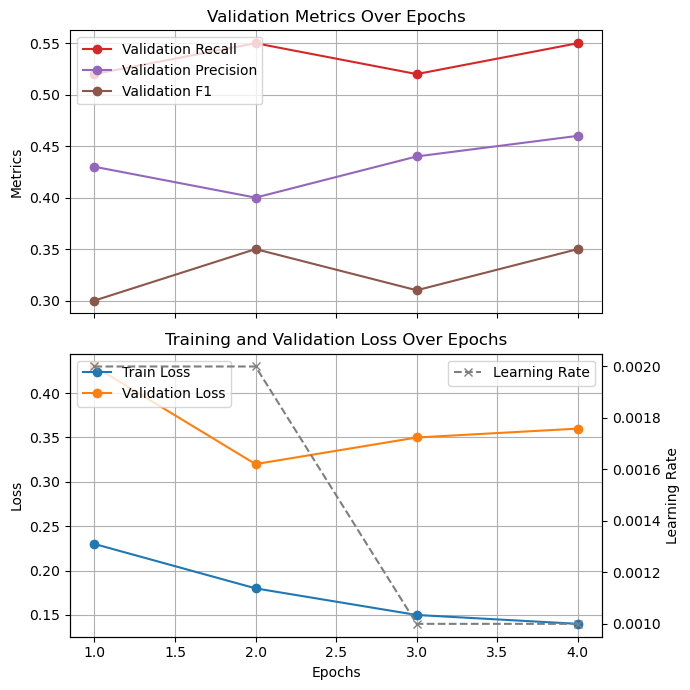

In [13]:
model_1.plot_training_history(figsize=(7,7))

In [14]:
model_2.unpickle("models/ML_poly_2.torch")

Model and train_story loaded


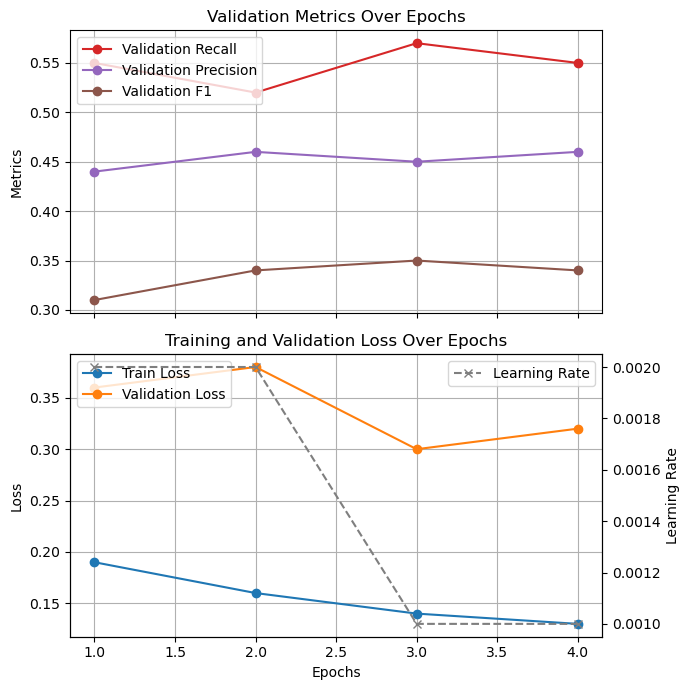

In [15]:
model_2.plot_training_history(figsize=(7,7))

In [ ]:
m1_val = model_1.test(VALIDATION_noindex)
m2_val = model_2.test(VALIDATION_with_index)
m1_test = model_1.test(TEST_noindex)
m2_test = model_2.test(TEST_with_index)

In [ ]:
def plot_model_metrics(m1_val, m2_val, m1_test, m2_test):
    metrics = ['test_recall', 'test_precision', 'test_f1']
    colors = ['b', 'g', 'r']
    markers = ['o', 's', 'D']

    m1_val_values = [m1_val[metric] for metric in metrics]
    m2_val_values = [m2_val[metric] for metric in metrics]
    m1_test_values = [m1_test[metric] for metric in metrics]
    m2_test_values = [m2_test[metric] for metric in metrics]

    x_positions = [1, 2]
    x_labels_m1 = x_labels_m2 = ['source', 'target']
    x_labels_compare = ['m1 target', '+ abs gain']

    fig, axs = plt.subplots(1, 3, figsize=(11, 8))

    for i, metric in enumerate(metrics):
        axs[0].plot(x_positions, [m1_val[metric], m1_test[metric]], color=colors[i], marker=markers[i], linestyle='--')
        m1_change = m1_test[metric] - m1_val[metric]
        m1_rel_change = (m1_change / m1_val[metric]) * 100 if m1_val[metric] != 0 else float('inf')
        axs[0].text(2.1, m1_test[metric], f'{m1_change:.3f}\n({m1_rel_change:.2f}%)', color=colors[i], fontsize=8, ha='left')

        axs[1].plot(x_positions, [m2_val[metric], m2_test[metric]], color=colors[i], marker=markers[i], linestyle='--')
        m2_change = m2_test[metric] - m2_val[metric]
        m2_rel_change = (m2_change / m2_val[metric]) * 100 if m2_val[metric] != 0 else float('inf')
        axs[1].text(2.1, m2_test[metric], f'{m2_change:.3f}\n({m2_rel_change:.2f}%)', color=colors[i], fontsize=8, ha='left')

        m2_drop = abs(m2_test[metric] - m2_val[metric])
        m1_val_adjusted = m1_val[metric] - m2_drop
        axs[2].plot(x_positions, [m1_test[metric], m1_val_adjusted], color=colors[i], marker=markers[i], linestyle='--', label=f'{metric[5:]}')
        comparison_change = m1_val_adjusted - m1_test[metric]
        comparison_rel_change = (comparison_change / m1_test[metric]) * 100 if m1_test[metric] != 0 else float('inf')
        axs[2].text(2.1, m1_val_adjusted, f'{comparison_change:.3f}\n(+{comparison_rel_change:.2f}%)', color=colors[i], fontsize=8, ha='left')

    for ax in axs:
        ax.set_xticks(x_positions)
        ax.set_xlim(0.6, 2.7)
        ax.set_ylim(0.25, 0.6)
        ax.grid(True, which="both", axis='y', linewidth=0.5)

    axs[0].set_xticklabels(x_labels_m1)
    axs[0].set_ylabel('Metrics')
    axs[0].set_title('m1: no DA')

    axs[1].set_xticklabels(x_labels_m2)
    axs[1].set_title('m2: with DA')

    axs[2].set_xticklabels(x_labels_compare)
    axs[2].set_title('m1 vs m2')

    fig.legend(loc='center left', bbox_to_anchor=(0.85, 0.5))
    fig.suptitle('Model Performance Metrics Comparison', fontsize=16)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

In [ ]:
plot_model_metrics(m1_val, m2_val, m1_test, m2_test)

## Export model scheme

In [ ]:
x = torch.randn(1, INPUT_CHANNELS_2, 512, 512).to('cuda')
y = model_2.model(x)
dot = make_dot(y, params=dict(model_2.model.named_parameters()))
dot.render('model_graph', format='pdf')